In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [2]:
digits = load_digits()
X = digits.data / 16.0
y = digits.target
y_onehot = np.zeros((y.size, 10))
y_onehot[np.arange(y.size), y] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

In [3]:
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x): return x * (1 - x)
def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)

In [4]:
input_size = 64
hidden_size = 32
output_size = 10
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

In [5]:
epochs = 50
lr = 0.1
losses = []
for epoch in range(epochs):
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = softmax(z2)
    loss = -np.mean(np.sum(y_train * np.log(a2 + 1e-8), axis=1))
    losses.append(loss)
    dz2 = a2 - y_train
    dW2 = np.dot(a1.T, dz2) / X_train.shape[0]
    db2 = np.sum(dz2, axis=0, keepdims=True) / X_train.shape[0]
    dz1 = np.dot(dz2, W2.T) * sigmoid_deriv(a1)
    dW1 = np.dot(X_train.T, dz1) / X_train.shape[0]
    db1 = np.sum(dz1, axis=0, keepdims=True) / X_train.shape[0]
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

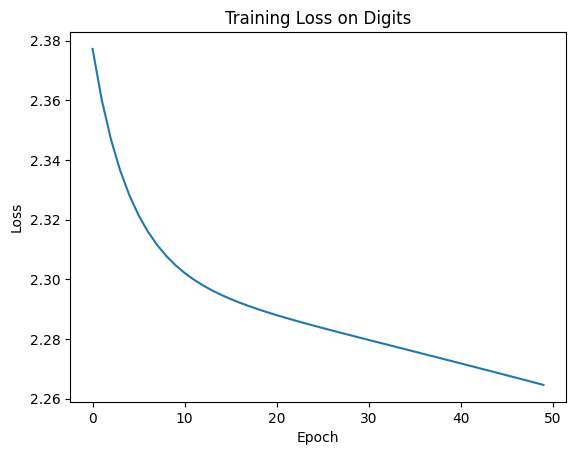

In [6]:
plt.plot(losses)
plt.title('Training Loss on Digits')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('digits_loss_plot.png')